<a href="https://colab.research.google.com/github/ShamimtheAnalyst/Crash-Course/blob/main/One_Sample_t_test_in_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **ভূমিকা (Introduction)**

One Sample t-test ব্যবহার করা হয় যখন আমরা জানতে চাই একটি স্যাম্পলের গড় (Mean) কি একটি নির্দিষ্ট মানের (Hypothesized Value) সমান কি না। এখানে আমরা চেক করব `mtcars` ডাটাসেটের গাড়ির গড় মাইলেজ ২০ এর সমান কি না।


### **১. ডেটা প্রস্তুতি এবং এক্সপ্লোরেশন (Data Preparation)**

শুরুতেই আমরা `mpg` কলামটি আলাদা করে নেব এবং এর ডিস্ট্রিবিউশন চেক করব।

In [ ]:
# ১. ডেটা প্রস্তুত করুন
data <- mtcars$mpg

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  10.40   15.43   19.20   20.09   22.80   33.90 

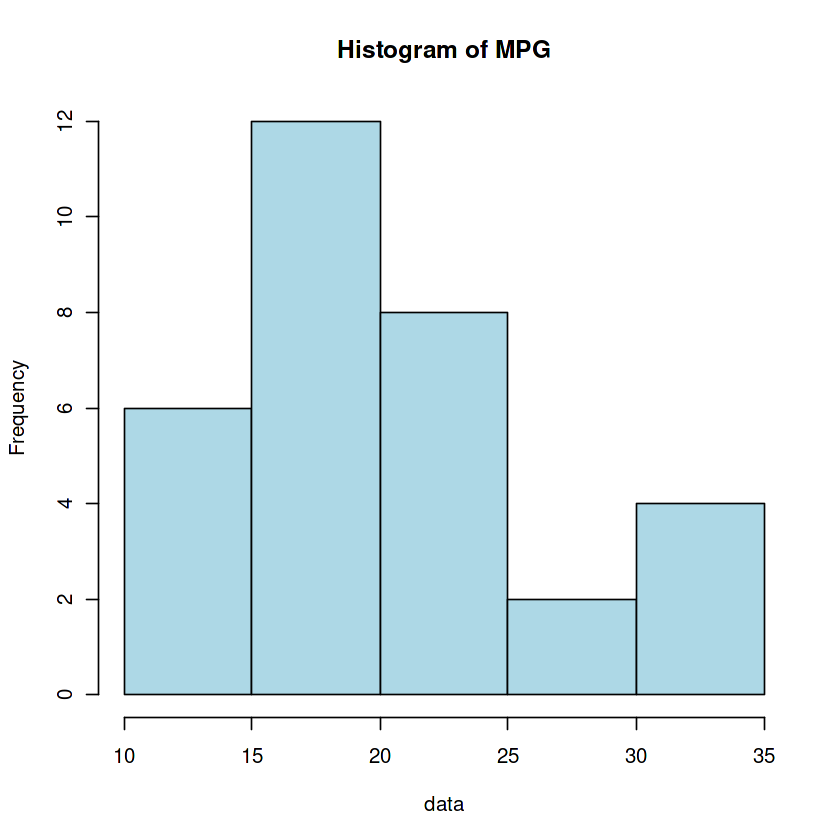

In [ ]:
# ২. ডেটা চেক করুন
summary(data)  # বেসিক স্ট্যাটিস্টিক্স
hist(data, main="Histogram of MPG", col="lightblue") # ভিজ্যুয়াল ডিস্ট্রিবিউশন


### **২. নর্মালিটি চেক (Normality Assumption)**

t-টেস্ট করার প্রধান শর্ত হলো ডেটা নর্মাল ডিস্ট্রিবিউটেড হতে হবে। এটি চেক করার জন্য আমরা **Shapiro-Wilk Test** ব্যবহার করি।

In [ ]:
# ৩. নর্মালিটি টেস্ট
shapiro.test(data)

# প্রো-টিপ: p-value > 0.05 হলে ডেটা নর্মাল ডিস্ট্রিবিউটেড বলে গণ্য হয়।


	Shapiro-Wilk normality test

data:  data
W = 0.94756, p-value = 0.1229


### **৩. t-টেস্ট সম্পাদন (Executing t-test)**

আমরা টেস্ট করছি যে গড় মাইলেজ কি ২০ কি না ()।

In [ ]:
# ৪. ওয়ান-স্যাম্পল t-টেস্ট
t_test_result <- t.test(data, mu = 20)
print(t_test_result)


	One Sample t-test

data:  data
t = 0.08506, df = 31, p-value = 0.9328
alternative hypothesis: true mean is not equal to 20
95 percent confidence interval:
 17.91768 22.26357
sample estimates:
mean of x 
 20.09062 



### **৪. ফলাফল বিশ্লেষণ (Result Interpretation)**

পরিসংখ্যানগত সিদ্ধান্তের জন্য নিচের লজিকটি ব্যবহৃত হয়:

In [ ]:
# ৫. ফলাফল ইন্টারপ্রেট
cat("p-value:", t_test_result$p.value, "\n")
cat("৯৫% কনফিডেন্স ইন্টারভাল:", t_test_result$conf.int, "\n")

if(t_test_result$p.value < 0.05) {
  cat("ফলাফল: গড় মাইলেজ ২০ mpg থেকে স্ট্যাটিস্টিক্যালি আলাদা (Reject H0)")
} else {
  cat("ফলাফল: গড় মাইলেজ ২০ mpg এর সাথে সামঞ্জস্যপূর্ণ (Fail to Reject H0)")
}

p-value: 0.9327606 
৯৫% কনফিডেন্স ইন্টারভাল: 17.91768 22.26357 
ফলাফল: গড় মাইলেজ ২০ mpg এর সাথে সামঞ্জস্যপূর্ণ (Fail to Reject H0)

### **৫. ভিজ্যুয়ালাইজেশন (Visualization)**

বক্সপ্লটের মাধ্যমে স্যাম্পল ডেটা এবং হাইপোথেসাইজড ভ্যালুর (২০) তুলনা করা হয়েছে।

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


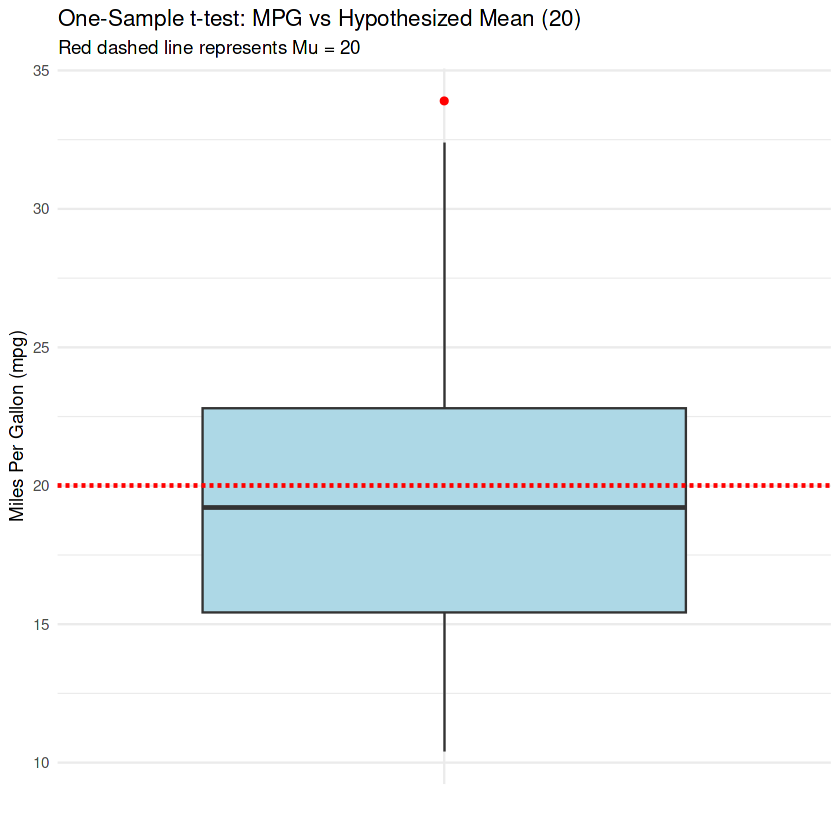

In [ ]:
library(tidyverse)

ggplot(mtcars, aes(x = "", y = mpg)) +
  geom_boxplot(fill = "lightblue", outlier.color = "red") +
  geom_hline(yintercept = 20, color = "red", linetype = "dashed", size = 1) +
  labs(title = "One-Sample t-test: MPG vs Hypothesized Mean (20)",
       subtitle = "Red dashed line represents Mu = 20",
       y = "Miles Per Gallon (mpg)", x = "") +
  theme_minimal()

### **৬. বিকল্প পদ্ধতি (Non-parametric Alternative)**

যদি আপনার ডেটা নর্মালিটি টেস্টে ফেল করে (অর্থাৎ নর্মাল ডিস্ট্রিবিউশন না হয়), তবে t-টেস্টের পরিবর্তে **Wilcoxon Signed Rank Test** ব্যবহার করতে হবে।

In [ ]:
# নন-প্যারামেট্রিক টেস্ট
wilcox.test(data, mu = 20)

Warning message in wilcox.test.default(data, mu = 20):
“cannot compute exact p-value with ties”



	Wilcoxon signed rank test with continuity correction

data:  data
V = 249, p-value = 0.7863
alternative hypothesis: true location is not equal to 20


### **সিস্টেম্যাটিক চেকলিস্ট (Summary Checklist):**

* **Shapiro-Wilk Test:** নর্মালিটি চেক করার জন্য।
* **t.test(data, mu = x):** t-টেস্ট সম্পাদন করার জন্য।
* **p-value < 0.05:** স্ট্যাটিস্টিক্যালি সিগনিফিকেন্ট বা তাৎপর্যপূর্ণ পার্থক্য নির্দেশ করে।
* **Wilcoxon Test:** যখন ডেটা নর্মাল থাকে না।

**দুর্দান্ত!** আপনি এখন স্ট্যাটিস্টিক্যাল ইনফারেন্সের একটি গুরুত্বপূর্ণ ধাপ শিখে ফেলেছেন।